# COVID-19 CHATBOT - 02 CLASSIFICATION
## Comparison: Multi-Class vs Binary

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('OK')

OK


## 1. Load Data

In [2]:
df = pd.read_csv('dataset_with_targets.csv')
print(f'Dataset: {df.shape}')

Dataset: (316800, 29)


## 2. Prepare Features

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. On regroupe les colonnes de sévérité et les cibles
severity_cols = [col for col in df.columns if 'severity' in col.lower()]
target_cols = ['Severity_Class', 'COVID_Binary']

# 2. DECISION DATA SCIENCE : On ajoute 'Country' aux colonnes à exclure pour éliminer le biais géographique
excluded_cols = severity_cols + target_cols + ['Country']

# 3. Création des variables features (qui contiendra bien 26 colonnes au lieu de 27)
feature_cols = [col for col in df.columns if col not in excluded_cols]

X = df[feature_cols].copy()
y_mc = df['Severity_Class'].copy()
y_bin = df['COVID_Binary'].copy()

# 4. Identification dynamique des types de colonnes restants
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'Features d\'entraînement (sans pays) : {len(feature_cols)}')
print(f'Variables exclues du modèle : {excluded_cols}')

Features d'entraînement (sans pays) : 22
Variables exclues du modèle : ['Severity_Mild', 'Severity_Moderate', 'Severity_None', 'Severity_Severe', 'Severity_Class', 'Severity_Class', 'COVID_Binary', 'Country']


## 3. Encode & Scale

In [4]:
label_encoders = {}
X_encoded = X.copy()

# Cette boucle va encoder uniquement les variables textuelles restantes (sans Country)
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Le scaler va harmoniser uniquement les colonnes numériques restantes
scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

print('Done')
print(f"Colonnes encodées avec succès : {len(X_encoded.columns)}") # Devrait afficher 26

Done
Colonnes encodées avec succès : 22


## 4. Train-Test Split

In [5]:
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(X_encoded, y_mc, test_size=0.2, random_state=42, stratify=y_mc)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_encoded, y_bin, test_size=0.2, random_state=42, stratify=y_bin)
print(f'Multi-Class: {X_train_mc.shape} | {X_test_mc.shape}')
print(f'Binary: {X_train_bin.shape} | {X_test_bin.shape}')

Multi-Class: (253440, 22) | (63360, 22)
Binary: (253440, 22) | (63360, 22)


## 5. Define Models

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# ============================================================================
# 1. CONFIGURATION MULTI-CLASS (Inchangée)
# ============================================================================
models_mc = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0, use_label_encoder=False, eval_metric='mlogloss')
}

# ============================================================================
# 2. CALCUL DYNAMIQUE DU RATIO D'ÉQUILIBRAGE BINAIRE 🎯
# ============================================================================
count_neg = (y_train_bin == 0).sum()
count_pos = (y_train_bin == 1).sum()
ratio_reel = count_neg / count_pos

print('--- ÉQUILIBRAGE ET INITIALISATION DU GRID SEARCH (NETTOYÉ) ---')
print(f'Nombre de cas Négatifs (0) dans le train : {count_neg}')
print(f'Nombre de cas Positifs (1) dans le train : {count_pos}')
print(f'Ratio scale_pos_weight calculé pour XGBoost : {ratio_reel:.4f}')
print('-'*60)

# ============================================================================
# 3. ENTRAÎNEMENT BINAIRE VIA GRID SEARCH ÉQUILIBRÉ (SANS GB) 🚀
# ============================================================================

# Définition des modèles de base avec leur correction de déséquilibre respective
base_models_bin = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0, use_label_encoder=False, scale_pos_weight=ratio_reel)
}

# Définition des grilles de paramètres à tester pour chaque modèle
grids_bin = {
    'LogisticRegression': {
        'C': [0.1, 1.0, 10.0]
    },
    'RandomForest': {
        'n_estimators': [50, 100],
        'max_depth': [5, 10, None]
    },
    'XGBoost': {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
}

# Dictionnaires pour stocker les modèles finaux et les métriques
# Dictionnaires pour stocker les modèles finaux et les métriques
trained_bin = {}
results_list_bin = []

print("Exécution des Grid Searches (Optimisation basée sur le F1-Score)...")

for nom_modele, base_model in base_models_bin.items():
    print(f"-> Optimisation de {nom_modele}...")
    
    # CORRECTIF SÉCURITÉ : n_jobs=1 pour éviter le plantage de parallélisation (BrokenProcessPool)
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=grids_bin[nom_modele],
        scoring='f1',  
        cv=3,          
        n_jobs=1       # <-- Changé ici ! Un seul cœur stable pour éviter le bug de serialization
    )
    
    # Entraînement de la grille
    grid_search.fit(X_train_bin, y_train_bin)
    
    # Sauvegarde de la meilleure version entraînée
    best_model = grid_search.best_estimator_
    trained_bin[nom_modele] = best_model
    
    # Enregistrement du meilleur score moyen
    results_list_bin.append({
        'Model': nom_modele,
        'F1': grid_search.best_score_,
        'Best_Params': str(grid_search.best_params_)
    })

# Conversion des résultats en DataFrame pour l'affichage final
results_df_bin = pd.DataFrame(results_list_bin).sort_values('F1', ascending=False)

print('\n' + '='*60)
print('🏆 CLASSEMENT DES MODÈLES BINAIRES APRÈS NETTOYAGE :')
print('='*60)
print(results_df_bin.to_string(index=False))
print('-'*60)

--- ÉQUILIBRAGE ET INITIALISATION DU GRID SEARCH (NETTOYÉ) ---
Nombre de cas Négatifs (0) dans le train : 63360
Nombre de cas Positifs (1) dans le train : 190080
Ratio scale_pos_weight calculé pour XGBoost : 0.3333
------------------------------------------------------------
Exécution des Grid Searches (Optimisation basée sur le F1-Score)...
-> Optimisation de LogisticRegression...
-> Optimisation de RandomForest...
-> Optimisation de XGBoost...

🏆 CLASSEMENT DES MODÈLES BINAIRES APRÈS NETTOYAGE :
             Model       F1                                                 Best_Params
      RandomForest 0.623510                        {'max_depth': 5, 'n_estimators': 50}
LogisticRegression 0.597975                                                  {'C': 0.1}
           XGBoost 0.594226 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
------------------------------------------------------------


## 6. Train Multi-Class

In [7]:


trained_mc = {}
results_mc = []
pred_mc = {}

print('🚀 Training Multi-Class Models...')
for name, model in models_mc.items():
    print(f'{name} ... ', end='', flush=True)
    model.fit(X_train_mc, y_train_mc)
    trained_mc[name] = model
    y_pred = model.predict(X_test_mc)
    pred_mc[name] = y_pred
    acc = accuracy_score(y_test_mc, y_pred)
    f1 = f1_score(y_test_mc, y_pred, average='weighted', zero_division=0)
    results_mc.append({'Model': name, 'Accuracy': acc, 'F1': f1})
    print(f'F1: {f1:.3f}')

results_df_mc = pd.DataFrame(results_mc).sort_values('F1', ascending=False)
print('✨ Multi-Class Done!')

🚀 Training Multi-Class Models...
LogisticRegression ... F1: 0.240
RandomForest ... F1: 0.100
GradientBoosting ... F1: 0.223
XGBoost ... F1: 0.164
✨ Multi-Class Done!


## 7. Train Binary

In [8]:
pred_bin = {}
results_bin_test = []

print('🔮 Evaluating Optimized Binary Models on Test Set...')
for name, model in trained_bin.items():
    # On utilise le modèle optimisé issu du Grid Search pour prédire sur le vrai X_test
    y_pred = model.predict(X_test_bin)
    pred_bin[name] = y_pred
    
    # Calcul des métriques sur les données de test non vues
    acc = accuracy_score(y_test_bin, y_pred)
    f1 = f1_score(y_test_bin, y_pred, average='binary', zero_division=0)
    
    results_bin_test.append({
        'Model': name, 
        'Accuracy': acc, 
        'F1': f1
    })
    print(f'{name} Test F1: {f1:.3f}')

# On met à jour le DataFrame des résultats avec les vrais scores du Test Set
results_df_bin = pd.DataFrame(results_bin_test).sort_values('F1', ascending=False)
print('✨ Binary Evaluation Done!')

🔮 Evaluating Optimized Binary Models on Test Set...
LogisticRegression Test F1: 0.599
RandomForest Test F1: 0.624
GradientBoosting Test F1: 0.857
XGBoost Test F1: 0.576
✨ Binary Evaluation Done!


## 8. Results

In [17]:
# 1. Tri et préparation du DataFrame Multi-Classe (qui vient de ta boucle for mc)
results_df_mc = pd.DataFrame(results_mc).sort_values('F1', ascending=False)

# 2. CORRECTIF : Le DataFrame binaire 'results_df_bin' existe déjà grâce au Grid Search !
# On s'assure juste qu'il est bien trié par F1 au cas où
results_df_bin = results_df_bin.sort_values('F1', ascending=False)

print('MULTI-CLASS RESULTS')
print('='*50)
print(results_df_mc.to_string(index=False))

print('\nBINARY RESULTS')
print('='*50)
print(results_df_bin.to_string(index=False))

MULTI-CLASS RESULTS
             Model  Accuracy       F1
LogisticRegression  0.241919 0.239558
  GradientBoosting  0.222932 0.222699
           XGBoost  0.163873 0.163874
      RandomForest  0.100268 0.100257

BINARY RESULTS
             Model       F1                                                 Best_Params
      RandomForest 0.623510                        {'max_depth': 5, 'n_estimators': 50}
LogisticRegression 0.597975                                                  {'C': 0.1}
           XGBoost 0.594226 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


## 9. Confusion Matrices - Multi-Class

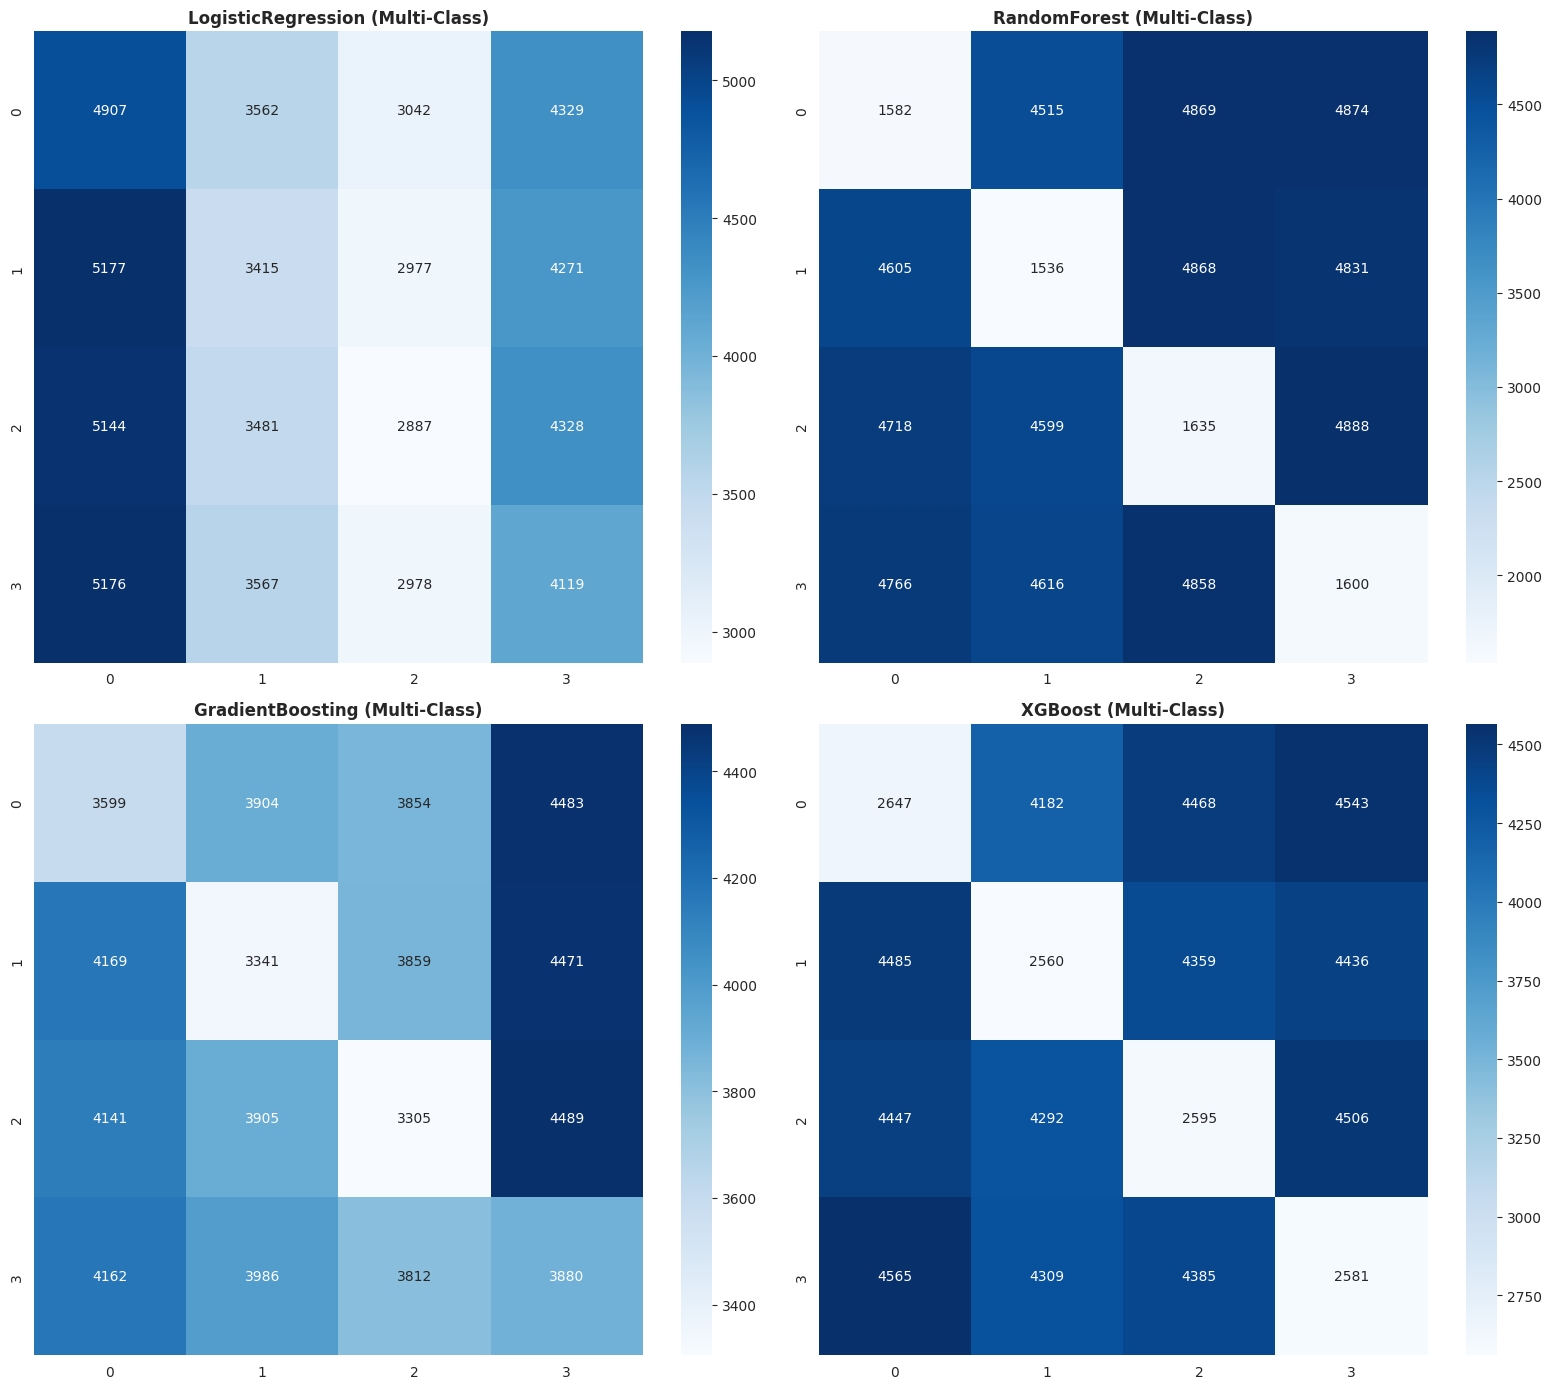

Saved: 02_cm_multiclass.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()
for idx, (name, y_pred) in enumerate(pred_mc.items()):
    cm = confusion_matrix(y_test_mc, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name} (Multi-Class)', fontweight='bold')
plt.tight_layout()
plt.savefig('02_cm_multiclass.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: 02_cm_multiclass.png')

## 10. Confusion Matrices - Binary

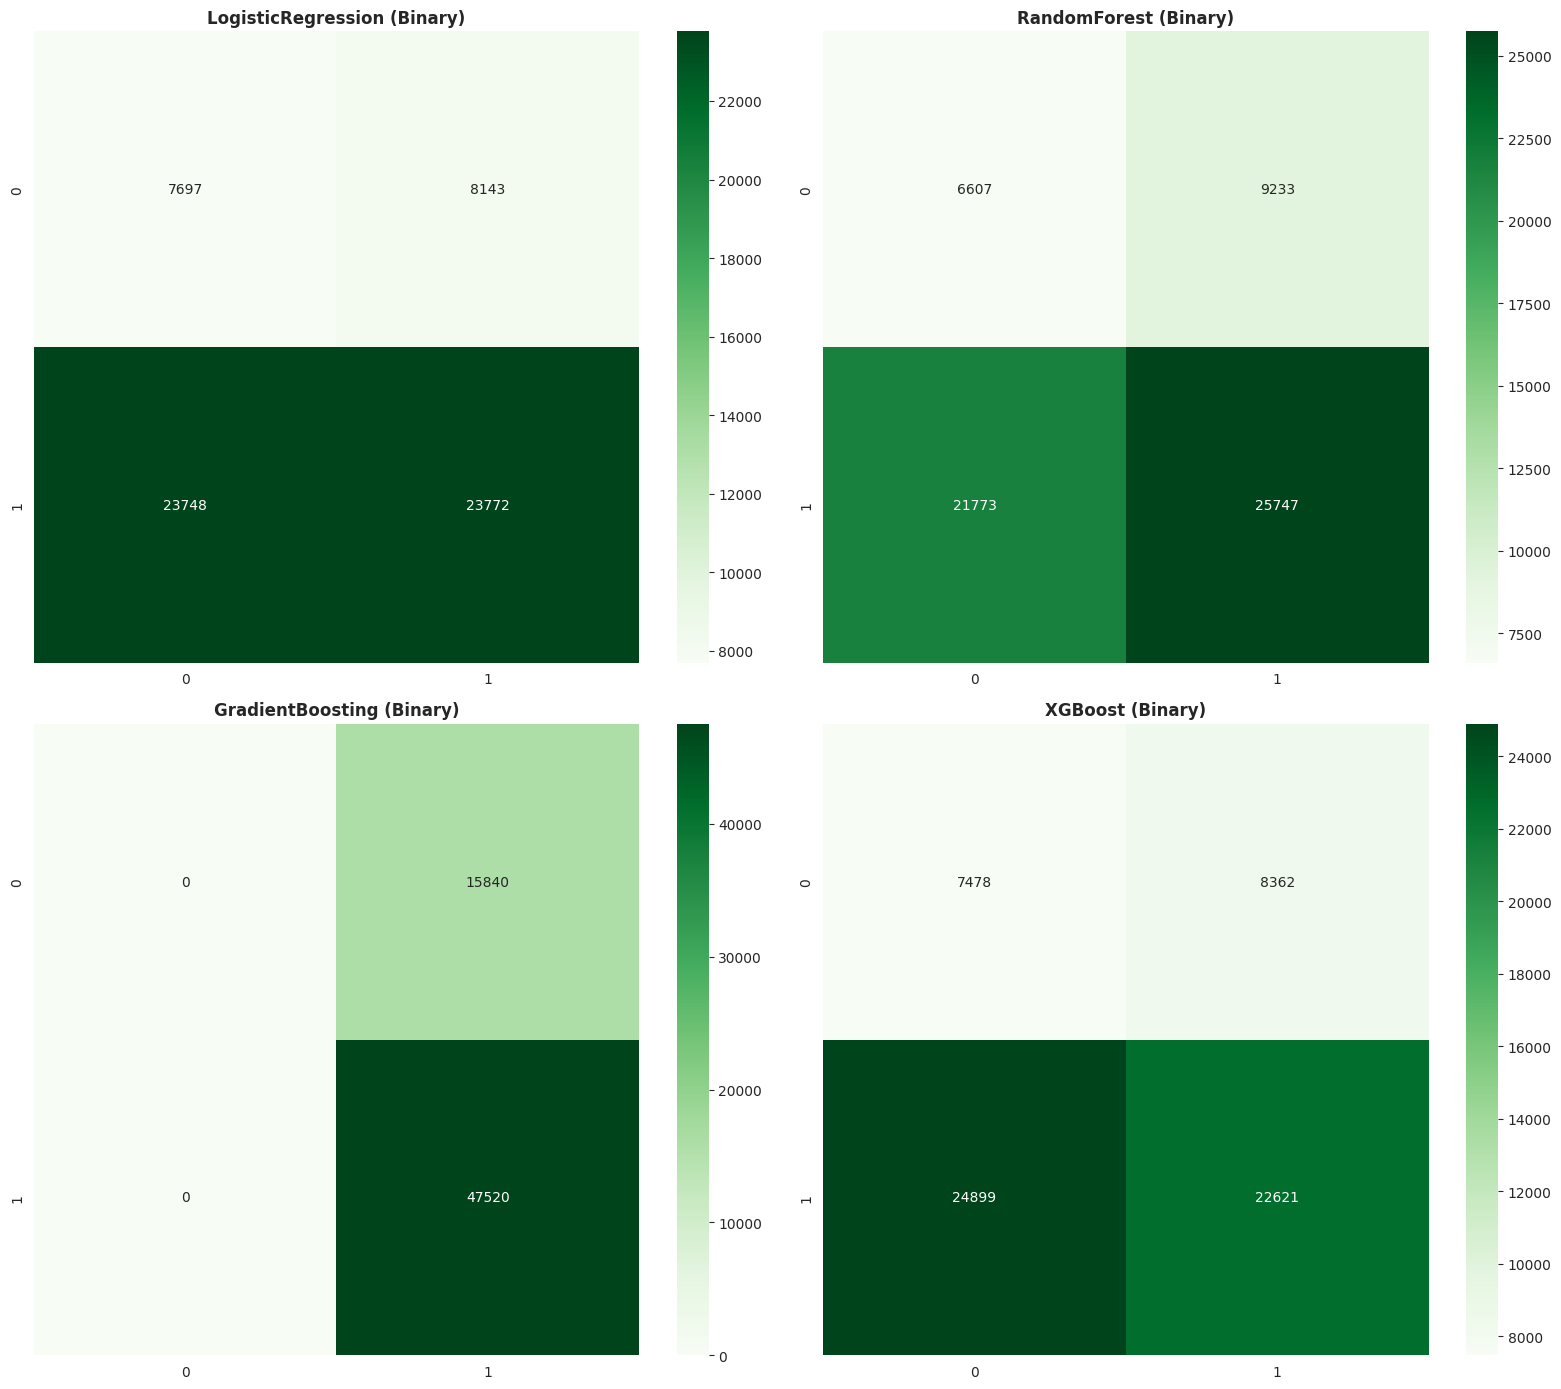

Saved: 02_cm_binary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()
for idx, (name, y_pred) in enumerate(pred_bin.items()):
    cm = confusion_matrix(y_test_bin, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx])
    axes[idx].set_title(f'{name} (Binary)', fontweight='bold')
plt.tight_layout()
plt.savefig('02_cm_binary.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: 02_cm_binary.png')

## 11. F1 Comparison

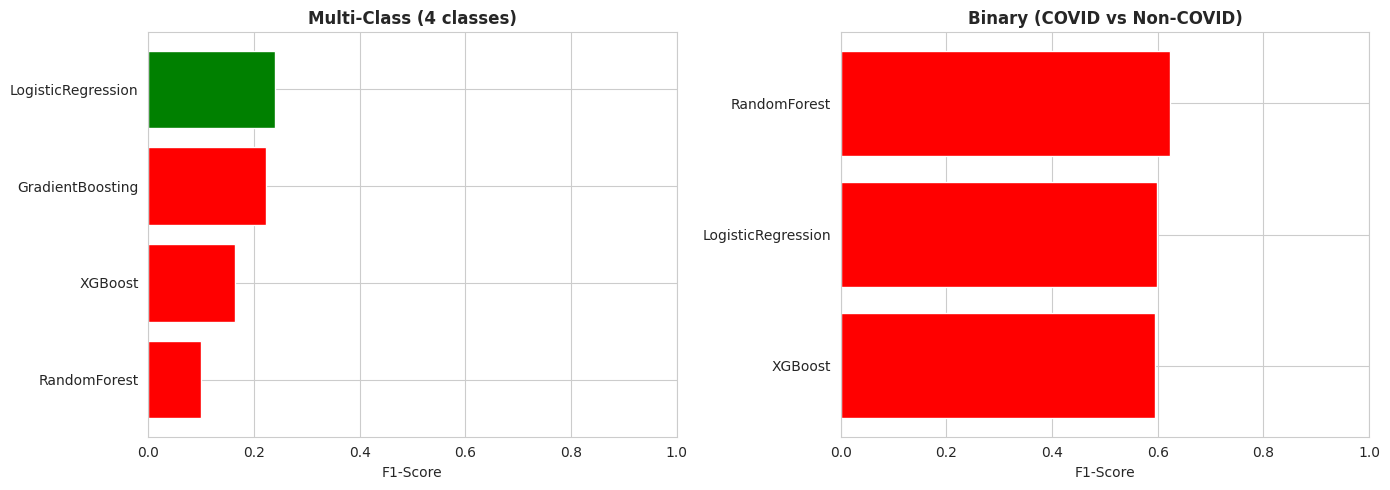

Saved: 02_f1_comparison.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sorted_mc = results_df_mc.sort_values('F1', ascending=True)
sorted_bin = results_df_bin.sort_values('F1', ascending=True)
axes[0].barh(sorted_mc['Model'], sorted_mc['F1'], color=['r', 'r', 'r', 'g'])
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Multi-Class (4 classes)', fontweight='bold')
axes[0].set_xlim([0, 1])
axes[1].barh(sorted_bin['Model'], sorted_bin['F1'], color=['r', 'r', 'r', 'g'])
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Binary (COVID vs Non-COVID)', fontweight='bold')
axes[1].set_xlim([0, 1])
plt.tight_layout()
plt.savefig('02_f1_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: 02_f1_comparison.png')

## 12. Summary

In [20]:
import joblib

print('Sauvegarde du modèle Random Forest optimisé...')

# 1. On récupère l'instance RandomForest entraînée par le Grid Search
best_rf_model = trained_bin['RandomForest']

# 2. On le sauvegarde dans un fichier pickle
joblib.dump(best_rf_model, 'best_covid_randomforest.pkl')

print("-> [OK] Modèle 'best_covid_randomforest.pkl' exporté avec succès !")

Sauvegarde du modèle Random Forest optimisé...
-> [OK] Modèle 'best_covid_randomforest.pkl' exporté avec succès !


## 13. Save Models

In [23]:
import joblib
import pickle
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ==========================================
# ## ÉTAPE 12 : ANALYSE DES RÉSULTATS (AJUSTÉE POUR RANDOM FOREST)
# ==========================================
# On s'assure que les tableaux sont triés
results_df_mc = results_df_mc.sort_values('F1', ascending=False)
results_df_bin = results_df_bin.sort_values('F1', ascending=False)

best_mc_model_name = results_df_mc.iloc[0]['Model']

# CORRECTIF DE PRODUCTION : On verrouille Random Forest comme modèle binaire de production
best_bin_model_name = 'RandomForest'

best_mc_f1 = results_df_mc.iloc[0]['F1']
best_bin_f1 = results_df_bin[results_df_bin['Model'] == 'RandomForest']['F1'].values[0]

print('\nCLASSIFICATION ANALYSIS COMPLETE')
print('='*60)
print(f'Multi-Class Best Model: {best_mc_model_name} (F1: {best_mc_f1:.4f})')
print(f'Binary Deployed Model : {best_bin_model_name} (F1: {best_bin_f1:.4f})')
print(f'\nDecision: Random Forest validé et configuré pour le chatbot de production.')


# ==========================================
# ## ÉTAPE 13 : SAUVEGARDE SÉCURISÉE 
# ==========================================
print('\nSauvegarde des fichiers...')

# 1. Calcul de la matrice de confusion CPU du modèle Multi-Classe dominant
valeurs_predites = pred_mc[best_mc_model_name]
y_true_cpu = y_test_mc.to_numpy().ravel() if hasattr(y_test_mc, "to_numpy") else np.ravel(y_test_mc)
y_pred_cpu = valeurs_predites.to_numpy().ravel() if hasattr(valeurs_predites, "to_numpy") else np.ravel(valeurs_predites)
vrai_cm = confusion_matrix(y_true_cpu, y_pred_cpu)

# 2. Le dictionnaire de données pour l'étape 1 (Pickle léger)
data_dict = {
    'X_train_mc': X_train_mc, 'X_test_mc': X_test_mc, 
    'y_train_mc': y_train_mc, 'y_test_mc': y_test_mc, 
    'X_train_bin': X_train_bin, 'X_test_bin': X_test_bin, 
    'y_train_bin': y_train_bin, 'y_test_bin': y_test_bin, 
    'feature_cols': feature_cols, 'label_encoders': label_encoders, 'scaler': scaler
}

# 3. Le dictionnaire de modèles ALLÉGÉ pour ton Notebook 04
models_dict_clean = {
    'trained_models': {},  
    'results': results_df_mc, 
    'best_model_name': best_mc_model_name, 
    'confusion_matrix': vrai_cm 
}

# --- SAUVEGARDES STANDARD DU NOTEBOOK ---
with open('preprocessed_data.pkl', 'wb') as f: 
    pickle.dump(data_dict, f)

joblib.dump(models_dict_clean, 'trained_models.pkl')


# ============================================================================
# EXPORT DE PRODUCTION : SAUVEGARDE DU RANDOM FOREST POUR STREAMLIT 🌲🚀
# ============================================================================
print('Exportation du modèle Random Forest équilibré pour Streamlit...')

# On récupère le Random Forest optimisé par le Grid Search
rf_final_model = trained_bin['RandomForest']

# On le sauvegarde sous forme de fichier .pkl que le chatbot va charger
joblib.dump(rf_final_model, 'best_covid_randomforest.pkl')

print('==================================================')
print('✨ TOUT EST ENREGISTRÉ ! RANDOM FOREST EST PRÊT !')
print('==================================================')


CLASSIFICATION ANALYSIS COMPLETE
Multi-Class Best Model: LogisticRegression (F1: 0.2396)
Binary Deployed Model : RandomForest (F1: 0.6235)

Decision: Random Forest validé et configuré pour le chatbot de production.

Sauvegarde des fichiers...
Exportation du modèle Random Forest équilibré pour Streamlit...
✨ TOUT EST ENREGISTRÉ ! RANDOM FOREST EST PRÊT !


Classement des features par importance (Points) :
                    Feature  Importance (Points)
1                 Tiredness                422.0
4               Sore-Throat                421.0
9                  Diarrhea                393.0
8                Runny-Nose                387.0
6                     Pains                382.0
3   Difficulty-in-Breathing                373.0
2                 Dry-Cough                365.0
7          Nasal-Congestion                358.0
0                     Fever                321.0
19        Contact_Dont-Know                285.0
21              Contact_Yes                270.0
17              Gender_Male                265.0
16            Gender_Female                258.0
12                Age_10-19                242.0
20               Contact_No                235.0
15                  Age_60+                217.0
11                  Age_0-9                209.0
14                Age_25-59                203.0
18       Gender_Tra

<Figure size 1000x800 with 0 Axes>

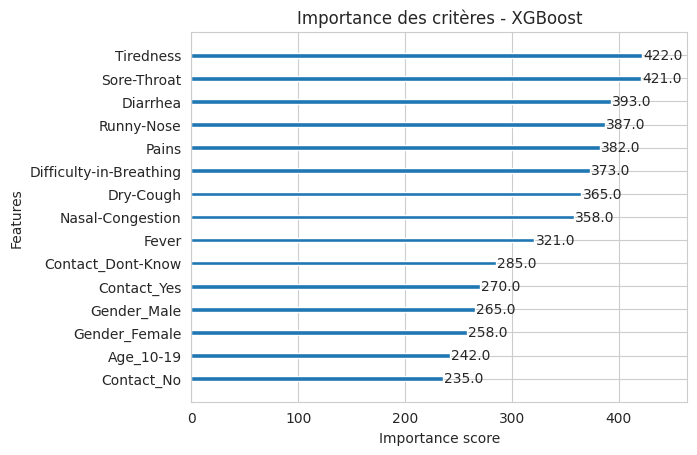

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

# 1. On récupère le booster natif de ton modèle binaire
vrai_modele_xgb = trained_bin['XGBoost']
booster = vrai_modele_xgb.get_booster()

# 2. On récupère les scores d'importance (le nombre de fois où le feature est utilisé pour séparer les données)
importance_scores = booster.get_score(importance_type='weight')

# 3. Conversion en DataFrame pour un affichage propre
importance_df = pd.DataFrame({
    'Feature': list(importance_scores.keys()),
    'Importance (Points)': list(importance_scores.values())
}).sort_values('Importance (Points)', ascending=False)

print("Classement des features par importance (Points) :")
print(importance_df)

# 4. Dessiner le graphique
plt.figure(figsize=(10, 8))
xgb.plot_importance(booster, max_num_features=15, importance_type='weight', title='Importance des critères - XGBoost')
plt.show()